<a href="https://colab.research.google.com/github/Nanji03/SOEN471_A2_Group20_Repo/blob/main/SOEN471_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## All the used dependencies

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import warnings
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Data Preprocessing
Steps:
- Load `ecommerce_user_data.csv` and `product_details.csv`
- Merge data if necessary
- Create user-item matrix
- Fill missing ratings with 0
- Group user behavior by category

In [ ]:
#Load datasets
user_data = pd.read_csv('/content/ecommerce_user_data.csv')
product_data = pd.read_csv('/content/product_details.csv')

print("User data shape:", user_data.shape)
print("Product data shape:", product_data.shape)
print("\nUser data preview:")
print(user_data.head())
print("\nProduct data preview:")
print(product_data.head())

User data shape: (724, 5)
Product data shape: (100, 3)

User data preview:
  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys

Product data preview:
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Clean datasets

#standardize column names
user_data.columns = user_data.columns.str.strip()
product_data.columns = product_data.columns.str.strip()

#remove duplicates
user_data = user_data.drop_duplicates()
product_data = product_data.drop_duplicates()

#convert timestamp to datetime
user_data["Timestamp"] = pd.to_datetime(user_data["Timestamp"], errors="coerce")

#ensure rating is numeric
user_data["Rating"] = pd.to_numeric(user_data["Rating"], errors="coerce")

#drop rows with critical missing values
user_data = user_data.dropna(subset=["UserID", "ProductID", "Rating", "Category"])
product_data = product_data.dropna(subset=["ProductID", "ProductName", "Category"])

#ratings in valid range
user_data = user_data[(user_data["Rating"] >= 1) & (user_data["Rating"] <= 5)]

print("\nMissing values after cleaning:")
print(user_data.isnull().sum())
print(product_data.isnull().sum())


Missing values after cleaning:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64
ProductID      0
ProductName    0
Category       0
dtype: int64


In [ ]:
#Merge user data with product details

merged_data = pd.merge(
    user_data,
    product_data,
    on="ProductID",
    how="left",
    suffixes=("_user", "_product")
)

#one final category column
#prefer product metadata category if available, otherwise use user dataset category
merged_data["FinalCategory"] = merged_data["Category_product"].fillna(merged_data["Category_user"])

print("\nMerged data preview:")
print(merged_data.head())


Merged data preview:
  UserID ProductID  Rating  Timestamp Category_user       ProductName  \
0   U000     P0009       5 2024-09-08         Books   Clothing Item 9   
1   U000     P0020       1 2024-09-02          Home  Clothing Item 20   
2   U000     P0012       4 2024-10-18         Books    Beauty Item 12   
3   U000     P0013       1 2024-09-18      Clothing  Clothing Item 13   
4   U000     P0070       4 2024-09-16          Toys    Beauty Item 70   

  Category_product FinalCategory  
0            Books         Books  
1             Home          Home  
2            Books         Books  
3         Clothing      Clothing  
4             Toys          Toys  


In [ ]:
#Create user-item matrix

user_item_matrix = merged_data.pivot_table(
    index="UserID",
    columns="ProductID",
    values="Rating",
    aggfunc="mean"
)

print("\nUser-item matrix shape:", user_item_matrix.shape)
print(user_item_matrix.head())


User-item matrix shape: (50, 100)
ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         NaN    NaN    NaN    3.0    NaN    5.0    NaN    3.0    NaN   
U001         NaN    NaN    3.0    NaN    NaN    NaN    NaN    NaN    NaN   
U002         NaN    NaN    NaN    NaN    NaN    5.0    NaN    NaN    NaN   
U003         NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U004         NaN    3.0    NaN    NaN    NaN    NaN    2.0    NaN    NaN   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U001         NaN  ...    NaN    5.0    NaN    NaN    NaN    3.0    NaN    NaN   
U002         NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U003         NaN  ...    Na

In [ ]:
#Handle missing ratings

#unrated items are filled with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

print("\nUser-item matrix after filling missing values:")
print(user_item_matrix_filled.head())


User-item matrix after filling missing values:
ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         0.0    0.0    0.0    3.0    0.0    5.0    0.0    3.0    0.0   
U001         0.0    0.0    3.0    0.0    0.0    0.0    0.0    0.0    0.0   
U002         0.0    0.0    0.0    0.0    0.0    5.0    0.0    0.0    0.0   
U003         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U004         0.0    3.0    0.0    0.0    0.0    0.0    2.0    0.0    0.0   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U001         0.0  ...    0.0    5.0    0.0    0.0    0.0    3.0    0.0    0.0   
U002         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U003         0

In [ ]:
#Group and aggregate purchase behavior

user_category_agg = (
    merged_data.groupby(["UserID", "FinalCategory"])
    .agg(
        TotalInteractions=("ProductID", "count"),
        AverageRating=("Rating", "mean"),
        UniqueProducts=("ProductID", "nunique")
    )
    .reset_index()
)

print("\nUser-category aggregated behavior:")
print(user_category_agg.head())


User-category aggregated behavior:
  UserID FinalCategory  TotalInteractions  AverageRating  UniqueProducts
0   U000         Books                  6       3.666667               6
1   U000      Clothing                  3       1.666667               3
2   U000   Electronics                  3       3.666667               3
3   U000          Home                  2       1.000000               2
4   U000          Toys                  6       3.500000               6


## Part 2: User-Based Collaborative Filtering
Steps:
- Use cosine similarity to compare users
- Recommend top-N products based on similar users
- Evaluate with Precision@K and Coverage

In [ ]:
## User based collaborative filtering: Calculate user similarity based on their ratings and recommend products, using cosine similarity
## To use adjusted cosine similarity, mean centered cosine similarity before calculate the cosine similarity
## std_user_item_matrix = user_item_matrix_filled.sub(user_item_matrix.mean(axis=1), axis=0)

user_similarity = cosine_similarity(user_item_matrix_filled)

# Create a DataFrame for user similarity
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix_filled.index, columns=user_item_matrix_filled.index)
print("\nUser Similarity Dataframe:")
print(user_similarity_df.head())



User Similarity Dataframe:
UserID      U000      U001      U002      U003      U004      U005      U006  \
UserID                                                                         
U000    1.000000  0.063071  0.195522  0.023466  0.065412  0.161251  0.160096   
U001    0.063071  1.000000  0.190861  0.000000  0.111332  0.009540  0.000000   
U002    0.195522  0.190861  1.000000  0.065094  0.111662  0.050830  0.027756   
U003    0.023466  0.000000  0.065094  1.000000  0.035737  0.104116  0.026650   
U004    0.065412  0.111332  0.111662  0.035737  1.000000  0.159064  0.057144   

UserID      U007      U008      U009  ...      U040      U041      U042  \
UserID                                ...                                 
U000    0.092083  0.238263  0.274844  ...  0.241693  0.129483  0.156790   
U001    0.172286  0.167460  0.017593  ...  0.121540  0.024075  0.097953   
U002    0.055877  0.000000  0.181229  ...  0.144756  0.000000  0.217465   
U003    0.000000  0.025384  0.288009

In [ ]:
## Recommend top-5 products to EACH user using similarity-weighted User-Based CF
## Improvement over naive approach: restrict to the top N_NEIGHBORS most similar users (positive-similarity only). Using ALL users adds noise from dissimilar users and hurts precision

N_NEIGHBORS = 10

def recommend_products(user_id, user_similarity_df, user_item_matrix, top_n=5,
                       n_neighbors=N_NEIGHBORS):

    sim_scores = user_similarity_df.loc[user_id].drop(user_id)

    ## Keeping only positively-similar neighbours, then take the closest n_neighbors
    positive_sim = sim_scores[sim_scores > 0]
    neighbours   = positive_sim.nlargest(n_neighbors) if not positive_sim.empty \
                   else sim_scores.nlargest(n_neighbors)

    ## Weighted sum of neighbours' ratings
    weighted_sum = user_item_matrix.loc[neighbours.index].T.dot(neighbours)

    ## Normalise to get predicted ratings on the same scale
    total_weight = neighbours.abs().sum()
    predicted    = weighted_sum / total_weight if total_weight > 0 else weighted_sum

    ## Filter out products the target user has already rated
    already_rated = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index
    predicted     = predicted.drop(already_rated, errors='ignore')

    return predicted.nlargest(top_n).index.tolist()

## Generate top-5 recommendations for ALL 50 users
all_recommendations = {
    uid: recommend_products(uid, user_similarity_df, user_item_matrix_filled, top_n=5)
    for uid in user_item_matrix_filled.index
}

## Display with product names
print("Top-5 Product Recommendations per User")
print("=" * 65)
for uid in list(user_item_matrix.index)[:50]:
    recs  = all_recommendations[uid]
    names = product_data[product_data['ProductID'].isin(recs)]['ProductName'].tolist()
    print(f"\n{uid}: {recs}")
    print(f"       {names}")

Top-5 Product Recommendations per User

U000: ['P0064', 'P0052', 'P0083', 'P0051', 'P0088']
       ['Home Item 51', 'Home Item 52', 'Electronics Item 64', 'Beauty Item 83', 'Clothing Item 88']

U001: ['P0070', 'P0039', 'P0064', 'P0093', 'P0061']
       ['Toys Item 39', 'Clothing Item 61', 'Electronics Item 64', 'Beauty Item 70', 'Electronics Item 93']

U002: ['P0070', 'P0033', 'P0003', 'P0091', 'P0006']
       ['Clothing Item 3', 'Books Item 6', 'Toys Item 33', 'Beauty Item 70', 'Clothing Item 91']

U003: ['P0070', 'P0060', 'P0043', 'P0098', 'P0093']
       ['Books Item 43', 'Toys Item 60', 'Beauty Item 70', 'Electronics Item 93', 'Electronics Item 98']

U004: ['P0070', 'P0049', 'P0051', 'P0089', 'P0005']
       ['Home Item 5', 'Toys Item 49', 'Home Item 51', 'Beauty Item 70', 'Clothing Item 89']

U005: ['P0088', 'P0082', 'P0093', 'P0073', 'P0060']
       ['Toys Item 60', 'Toys Item 73', 'Toys Item 82', 'Clothing Item 88', 'Electronics Item 93']

U006: ['P0004', 'P0051', 'P0052', 'P007

In [ ]:
def train_test_split_per_user(matrix, test_ratio=0.2, random_state=42):
    rng   = np.random.default_rng(random_state)
    train = matrix.copy()
    test  = {}
    for uid in matrix.index:
        rated  = matrix.loc[uid][matrix.loc[uid] > 0].index.tolist()
        n_test = max(1, int(len(rated) * test_ratio))
        held   = list(rng.choice(rated, size=n_test, replace=False))
        ## Mask held-out ratings in train
        train.loc[uid, held] = 0
        test[uid] = held
    return train, test

def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & set(relevant)) / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended[:k]) & set(relevant)) / len(relevant)

def average_precision(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    hits, sum_prec = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits     += 1
            sum_prec += hits / (i + 1)
    return sum_prec / min(len(relevant), k)

def catalog_coverage(recommendations, n_products):
    unique = {p for recs in recommendations.values() for p in recs}
    return len(unique) / n_products

def intra_list_diversity(recommendations, item_matrix):
    item_vecs   = item_matrix.T
    diversities = []
    for uid, recs in recommendations.items():
        valid = [r for r in recs if r in item_vecs.index]
        if len(valid) < 2:
            diversities.append(0.0)
            continue
        vecs = item_vecs.loc[valid].values
        sim  = cosine_similarity(vecs)
        n    = len(valid)
        pairs = [(1 - sim[i][j]) for i in range(n) for j in range(i+1, n)]
        diversities.append(np.mean(pairs))
    return float(np.mean(diversities))

## Build train and test split
train_matrix, test_dict = train_test_split_per_user(user_item_matrix_filled)

## Recalculate cosine similarity on training data only
train_sim_df = pd.DataFrame(
    cosine_similarity(train_matrix),
    index=train_matrix.index,
    columns=train_matrix.index
)

## Recommend top-5 for every user using the training matrix
K = 5
train_recs = {
    uid: recommend_products(uid, train_sim_df, train_matrix, top_n=K)
    for uid in train_matrix.index
}

## Compute metrics: Precisin@5 and Coverage
precisions   = [precision_at_k(train_recs[uid], test_dict[uid], K)for uid in train_matrix.index]

recalls    = [recall_at_k   (train_recs[uid], test_dict[uid], K)    for uid in train_matrix.index]

avg_precs  = [average_precision(train_recs[uid], test_dict[uid], K) for uid in train_matrix.index]

avg_prec_k = np.mean(precisions)
avg_rec_k  = np.mean(recalls)
## Mean Average Precision
map_score  = np.mean(avg_precs)
coverage   = catalog_coverage(train_recs, len(user_item_matrix_filled.columns))
diversity  = intra_list_diversity(train_recs, user_item_matrix_filled)


print("=" * 56)
print(f"  Model Evaluation  (User-Based CF,  K = {K})")
print("=" * 56)
print(f"  Average Precision@{K}      :  {avg_prec_k:.4f}")
print(f"  Average Recall@{K}         :  {avg_rec_k:.4f}")
print(f"  Mean Average Precision    :  {map_score:.4f}")
print(f"  Catalog Coverage          :  {coverage:.4f}  ({coverage*100:.1f}%)")
print(f"  Intra-List Diversity      :  {diversity:.4f}")
print("=" * 56)

print(f"Per-user Metrics K = {K}")
print(f"{'UserID':<8}  {'P@K':>6}  {'R@K':>6}  {'AP':>6}  {'Held-out (test)'}")
print("-" * 70)
for uid in list(train_matrix.index)[:50]:
    p  = precision_at_k(train_recs[uid], test_dict[uid], K)
    r  = recall_at_k   (train_recs[uid], test_dict[uid], K)
    ap = average_precision(train_recs[uid], test_dict[uid], K)
    print(f"{uid:<8}  {p:>6.2f}  {r:>6.2f}  {ap:>6.2f}  {str(test_dict[uid])}")


  Model Evaluation  (User-Based CF,  K = 5)
  Average Precision@5      :  0.0440
  Average Recall@5         :  0.0917
  Mean Average Precision    :  0.0281
  Catalog Coverage          :  0.6900  (69.0%)
  Intra-List Diversity      :  0.7944
Per-user Metrics K = 5
UserID       P@K     R@K      AP  Held-out (test)
----------------------------------------------------------------------
U000        0.00    0.00    0.00  [np.str_('P0021'), np.str_('P0005'), np.str_('P0044'), np.str_('P0046')]
U001        0.00    0.00    0.00  [np.str_('P0030'), np.str_('P0054')]
U002        0.00    0.00    0.00  [np.str_('P0059'), np.str_('P0086')]
U003        0.00    0.00    0.00  [np.str_('P0065'), np.str_('P0097')]
U004        0.00    0.00    0.00  [np.str_('P0050'), np.str_('P0092'), np.str_('P0011')]
U005        0.00    0.00    0.00  [np.str_('P0048'), np.str_('P0036')]
U006        0.00    0.00    0.00  [np.str_('P0064'), np.str_('P0065')]
U007        0.00    0.00    0.00  [np.str_('P0072'), np.str_('P0

## Part 3: Association Rule Mining (Apriori)
Steps:
- Convert user-product interactions to transaction format
- Apply Apriori algorithm to find frequent itemsets
- Generate association rules (support, confidence, lift)

In [ ]:
# Suppress deprecation warnings for clean output
warnings.filterwarnings('ignore')

# 1. Convert user-product interactions to transaction format using Product Names
transactions = merged_data.groupby('UserID')['ProductName'].apply(list).tolist()

# 2. Initialize and apply the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# 3. Apply Apriori to find frequent itemsets (min_support = 0.05)
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)

# 4. Generate association rules (min_threshold = 0.5)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

# 5. Sort the rules by 'lift' to find the strongest associations
top_rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

# Display the top 10 actionable association rules
print("Top 10 Association Rules Discovered:")
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Top 10 Association Rules Discovered:


,antecedents,consequents,support,confidence,lift
416,"(Beauty Item 50, Home Item 52)","(Books Item 6, Books Item 11)",0.06,1.0,16.666667
417,"(Books Item 6, Home Item 52)","(Beauty Item 50, Books Item 11)",0.06,1.0,16.666667
420,"(Beauty Item 50, Books Item 11)","(Books Item 6, Home Item 52)",0.06,1.0,16.666667
421,"(Books Item 6, Books Item 11)","(Beauty Item 50, Home Item 52)",0.06,1.0,16.666667
458,"(Clothing Item 88, Clothing Item 13)","(Clothing Item 44, Electronics Item 64)",0.06,1.0,16.666667
459,"(Clothing Item 44, Electronics Item 64)","(Clothing Item 88, Clothing Item 13)",0.06,1.0,16.666667
486,"(Home Item 79, Clothing Item 88)","(Electronics Item 64, Clothing Item 13)",0.06,1.0,16.666667
491,"(Electronics Item 64, Clothing Item 13)","(Home Item 79, Clothing Item 88)",0.06,1.0,16.666667
496,"(Home Item 79, Clothing Item 88)","(Clothing Item 44, Electronics Item 64)",0.06,1.0,16.666667
501,"(Clothing Item 44, Electronics Item 64)","(Home Item 79, Clothing Item 88)",0.06,1.0,16.666667


In [ ]:
# Apply Apriori and generate rules
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(Beauty Item 12),(Beauty Item 50),0.06,0.5,2.777778
1,(Beauty Item 12),(Beauty Item 70),0.06,0.5,1.470588
2,(Beauty Item 12),(Books Item 7),0.06,0.5,3.571429
3,(Beauty Item 12),(Clothing Item 9),0.06,0.5,3.125000
4,(Beauty Item 12),(Electronics Item 28),0.06,0.5,3.571429


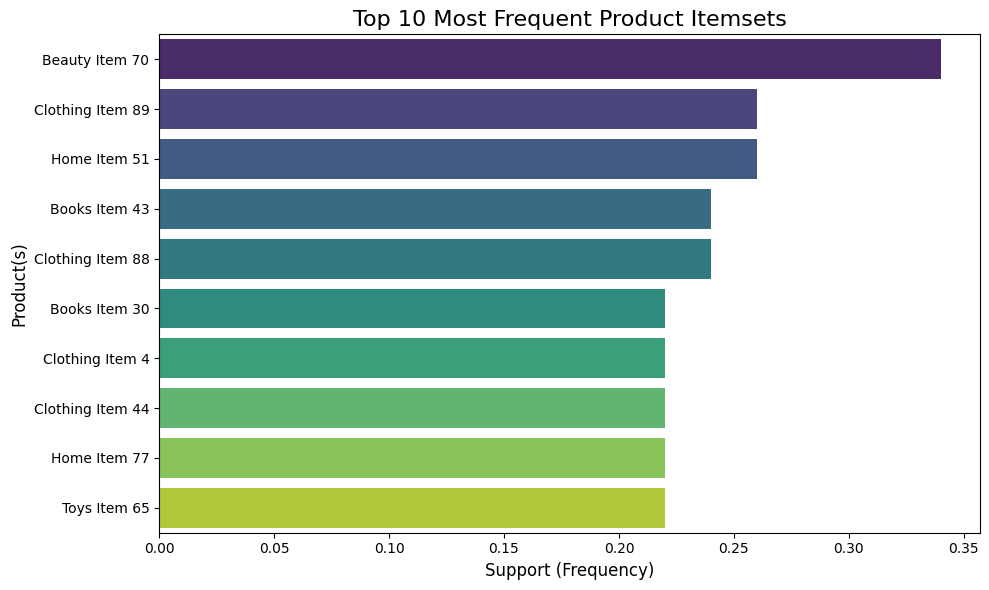

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress deprecation warnings for clean output
warnings.filterwarnings('ignore')

# 1. Convert the 'frozenset' items into clean strings for plotting
frequent_itemsets['itemsets_str'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

# 2. Extract the top 10 most frequent itemsets based on support
top_itemsets = frequent_itemsets.nlargest(10, 'support')

# 3. Set up and draw the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets_str', data=top_itemsets, palette='viridis')

# 4. Format the chart with titles and labels
plt.title('Top 10 Most Frequent Product Itemsets', fontsize=16)
plt.xlabel('Support (Frequency)', fontsize=12)
plt.ylabel('Product(s)', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

## Part 4: Visualization
Steps:
- Plot user similarity heatmap
- Visualize top recommendations
- Plot top frequent itemsets

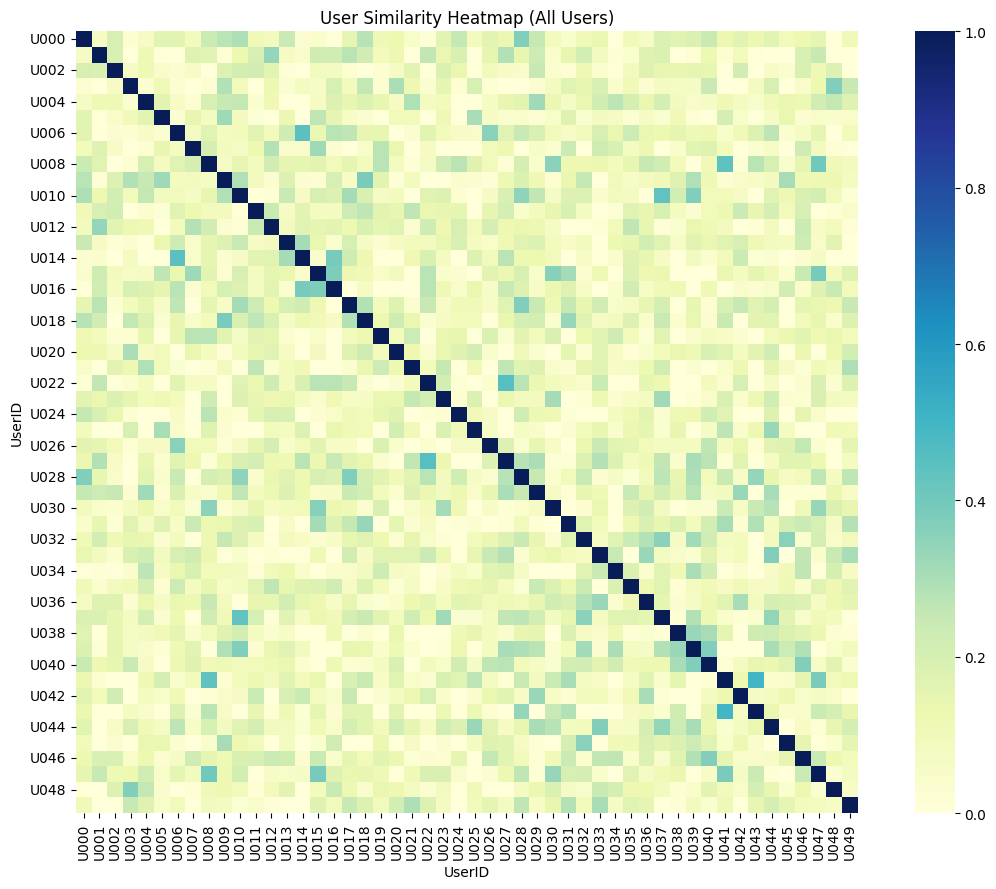

In [ ]:
#User similarity heatmaps
plt.figure(figsize=(12, 9))
sns.heatmap(user_similarity_df, cmap="YlGnBu", square=True)
plt.title("User Similarity Heatmap (All Users)")
plt.xlabel("UserID")
plt.ylabel("UserID")
plt.tight_layout()
plt.show()

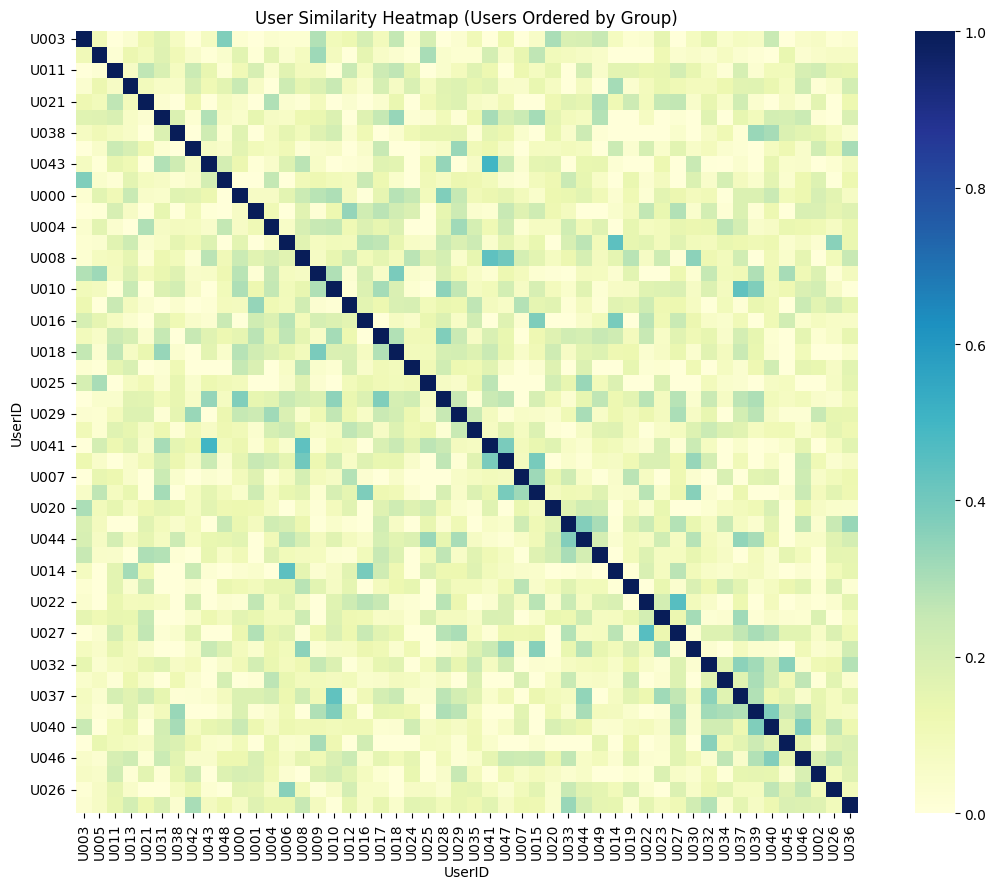

In [ ]:
user_groups = (
    merged_data.groupby(["UserID", "FinalCategory"])
        .size()
        .reset_index(name="Count")
        .sort_values(["UserID", "Count"], ascending=[True, False])
        .drop_duplicates("UserID")
        .rename(columns={"FinalCategory": "UserGroup"})
)

ordered_users = user_groups.sort_values(["UserGroup", "UserID"])["UserID"].tolist()
similarity_by_group = user_similarity_df.loc[ordered_users, ordered_users]

plt.figure(figsize=(12, 9))
sns.heatmap(similarity_by_group, cmap="YlGnBu", square=True)
plt.title("User Similarity Heatmap (Users Ordered by Group)")
plt.xlabel("UserID")
plt.ylabel("UserID")
plt.tight_layout()
plt.show()

In [ ]:
#Top-5 product recommendations for each user group

#convert the dictionary of recommendations into DataFrame
all_recs_list = []
for user_id, product_ids in all_recommendations.items():
    for product_id in product_ids:
        all_recs_list.append({'UserID': user_id, 'ProductID': product_id, 'Score': 1.0})

all_user_recommendations = pd.DataFrame(all_recs_list)

#Merge with product_data to get ProductName and Category details
all_user_recommendations = pd.merge(
    all_user_recommendations,
    product_data[['ProductID', 'ProductName', 'Category']],
    on='ProductID',
    how='left'
)

group_recommendations = (
    all_user_recommendations
    .merge(user_groups, on="UserID", how="left")
    .groupby(["UserGroup", "ProductID", "ProductName", "Category"], dropna=False)
    .agg(
        MeanRecommendationScore=("Score", "mean"),
        RecommendedToUsers=("UserID", "nunique")
    )
    .reset_index()
)

group_recommendations["GroupRankScore"] = (
    0.7 * group_recommendations["MeanRecommendationScore"] +
    0.3 * group_recommendations["RecommendedToUsers"]
)

top5_group_recommendations = (
    group_recommendations
    .sort_values(["UserGroup", "GroupRankScore", "MeanRecommendationScore"], ascending=[True, False, False])
    .groupby("UserGroup")
    .head(5)
    .reset_index(drop=True)
)

display(top5_group_recommendations)

,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers,GroupRankScore
0,Beauty,P0070,Beauty Item 70,Toys,1.0,6,2.5
1,Beauty,P0065,Toys Item 65,Clothing,1.0,4,1.9
2,Beauty,P0008,Books Item 8,Electronics,1.0,2,1.3
3,Beauty,P0021,Electronics Item 21,Electronics,1.0,2,1.3
4,Beauty,P0033,Toys Item 33,Books,1.0,2,1.3
5,Books,P0039,Toys Item 39,Electronics,1.0,7,2.8
6,Books,P0051,Home Item 51,Clothing,1.0,6,2.5
7,Books,P0070,Beauty Item 70,Toys,1.0,6,2.5
8,Books,P0003,Clothing Item 3,Electronics,1.0,3,1.6
9,Books,P0030,Books Item 30,Books,1.0,3,1.6


In [ ]:
#Tabular summary for report/dashboard use
group_summary = user_groups.groupby("UserGroup").agg(
    UsersInGroup=("UserID", "nunique")
).reset_index()

display(group_summary)

for group_id in sorted(top5_group_recommendations["UserGroup"].dropna().unique()):
    print(f"\nTop-5 recommendations for User Group {group_id}")
    display(
        top5_group_recommendations.loc[top5_group_recommendations["UserGroup"] == group_id, [
            "UserGroup", "ProductID", "ProductName", "Category",
            "MeanRecommendationScore", "RecommendedToUsers"
        ]].reset_index(drop=True)
    )

,UserGroup,UsersInGroup
0,Beauty,10
1,Books,18
2,Clothing,6
3,Electronics,13
4,Toys,3



Top-5 recommendations for User Group Beauty


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Beauty,P0070,Beauty Item 70,Toys,1.0,6
1,Beauty,P0065,Toys Item 65,Clothing,1.0,4
2,Beauty,P0008,Books Item 8,Electronics,1.0,2
3,Beauty,P0021,Electronics Item 21,Electronics,1.0,2
4,Beauty,P0033,Toys Item 33,Books,1.0,2



Top-5 recommendations for User Group Books


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Books,P0039,Toys Item 39,Electronics,1.0,7
1,Books,P0051,Home Item 51,Clothing,1.0,6
2,Books,P0070,Beauty Item 70,Toys,1.0,6
3,Books,P0003,Clothing Item 3,Electronics,1.0,3
4,Books,P0030,Books Item 30,Books,1.0,3


...

,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Clothing,P0030,Books Item 30,Books,1.0,3
1,Clothing,P0043,Books Item 43,Clothing,1.0,2
2,Clothing,P0044,Clothing Item 44,Books,1.0,2
3,Clothing,P0054,Home Item 54,Toys,1.0,2
4,Clothing,P0064,Electronics Item 64,Electronics,1.0,2



Top-5 recommendations for User Group Electronics


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Electronics,P0088,Clothing Item 88,Books,1.0,6
1,Electronics,P0071,Beauty Item 71,Toys,1.0,5
2,Electronics,P0029,Books Item 29,Electronics,1.0,4
3,Electronics,P0065,Toys Item 65,Clothing,1.0,4
4,Electronics,P0070,Beauty Item 70,Toys,1.0,4



Top-5 recommendations for User Group Toys


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Toys,P0043,Books Item 43,Clothing,1.0,2
1,Toys,P0070,Beauty Item 70,Toys,1.0,2
2,Toys,P0003,Clothing Item 3,Electronics,1.0,1
3,Toys,P0006,Books Item 6,Books,1.0,1
4,Toys,P0008,Books Item 8,Electronics,1.0,1


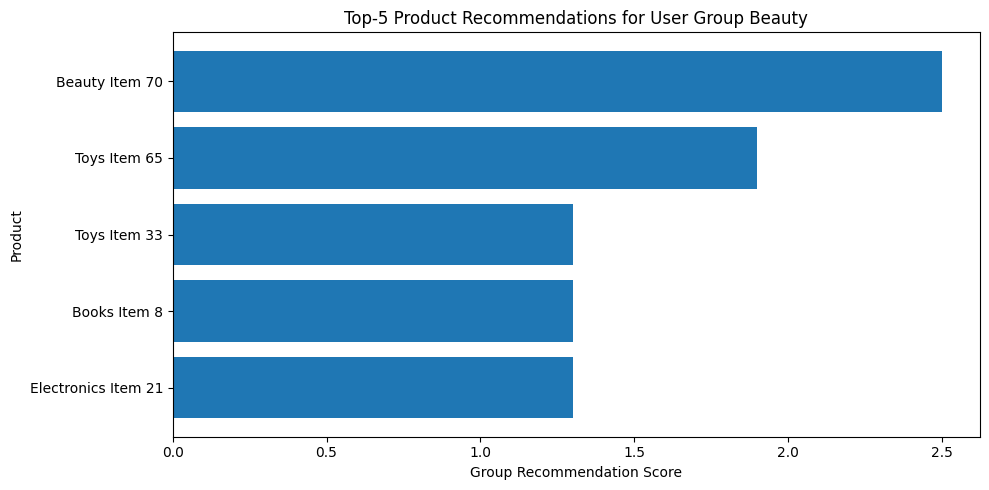

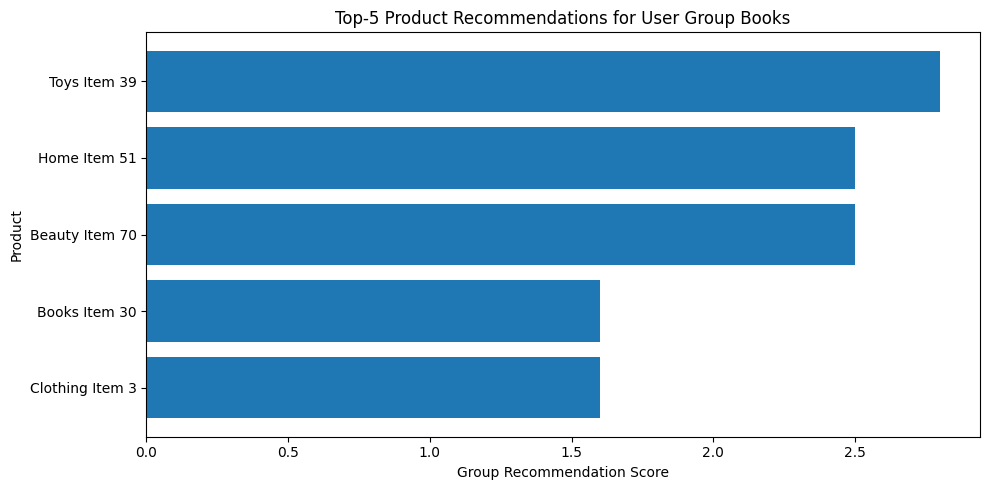

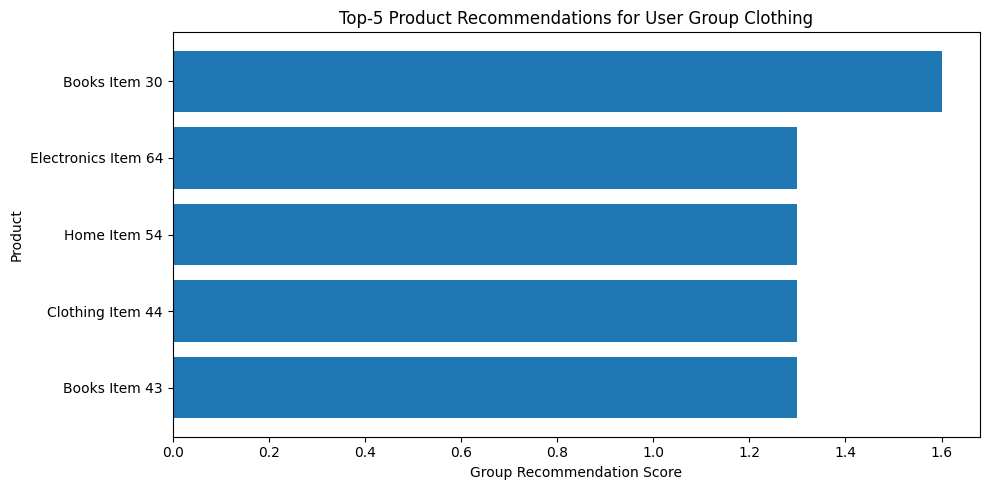

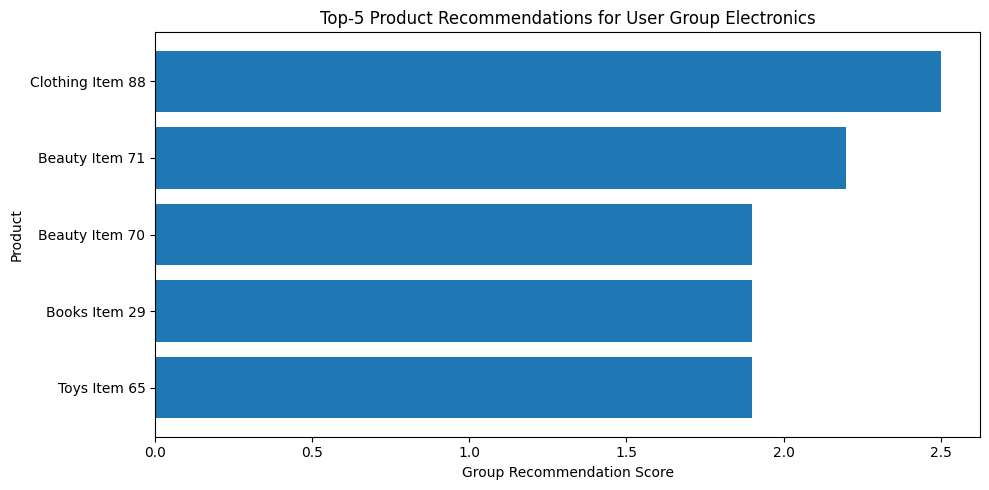

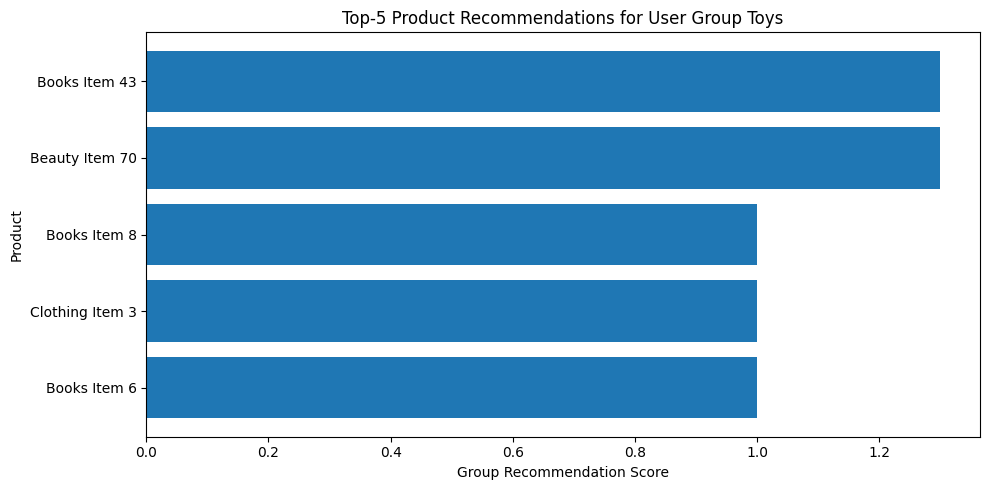

In [ ]:
#Visualization 3: bar chart for each user group's top-5 recommendations
for group_id in sorted(top5_group_recommendations["UserGroup"].dropna().unique()):
    plot_df = (
        top5_group_recommendations[top5_group_recommendations["UserGroup"] == group_id]
        .sort_values("GroupRankScore", ascending=True)
    )

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["ProductName"].fillna(plot_df["ProductID"]), plot_df["GroupRankScore"])
    plt.title(f"Top-5 Product Recommendations for User Group {group_id}")
    plt.xlabel("Group Recommendation Score")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

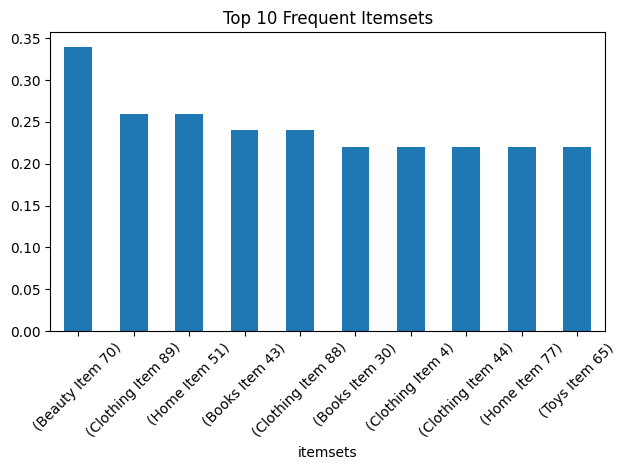

In [ ]:
# Frequent itemsets bar chart
frequent_itemsets.nlargest(10, 'support').plot(kind='bar', x='itemsets', y='support', legend=False)
plt.title('Top 10 Frequent Itemsets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()